In [1]:
import pandas as pd
import numpy as np

Pandas is loaded to work with tabular data. NumPy is loaded to handle the numerical calculations in Python.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is imported to plot charts and graphs. Seaborn is loaded on top of Matplotlib to help create graphs of the data. 

In [3]:
sns.set_style('whitegrid')
sns.set_palette('deep')

These lines of code set a style and palette for the graphs created.

In [4]:
NHTS_Data = pd.read_csv('NHTS.csv')
ngsim_data = pd.read_csv('NGSIM.csv')

These lines of code read the CSV files for the two datasets into pandas for analysis in Python.

<Figure size 2000x1000 with 0 Axes>

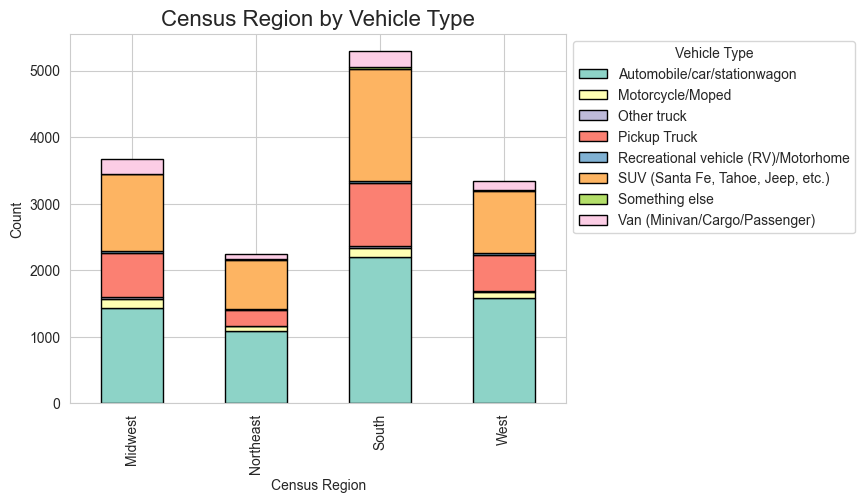

In [119]:
NHTS_Data = NHTS_Data.dropna(subset=['census_region'])
grouped_data = NHTS_Data.groupby(['census_region', 'vehicle_type']).size().unstack(fill_value=0)
plt.figure(figsize=(20, 10))
grouped_data.plot(kind='bar', stacked=True ,color=sns.color_palette('Set3', len(grouped_data.columns)), edgecolor='black')
plt.legend(title='Vehicle Type', bbox_to_anchor=(1, 1), loc='upper left')
plt.title('Census Region by Vehicle Type', fontsize=16)
plt.xlabel('Census Region')
plt.ylabel('Count')
plt.show()

The above code graphs the Census Region vs. Vehicle type to show the relationship of the ranges of each vehicle type with its geographic location.

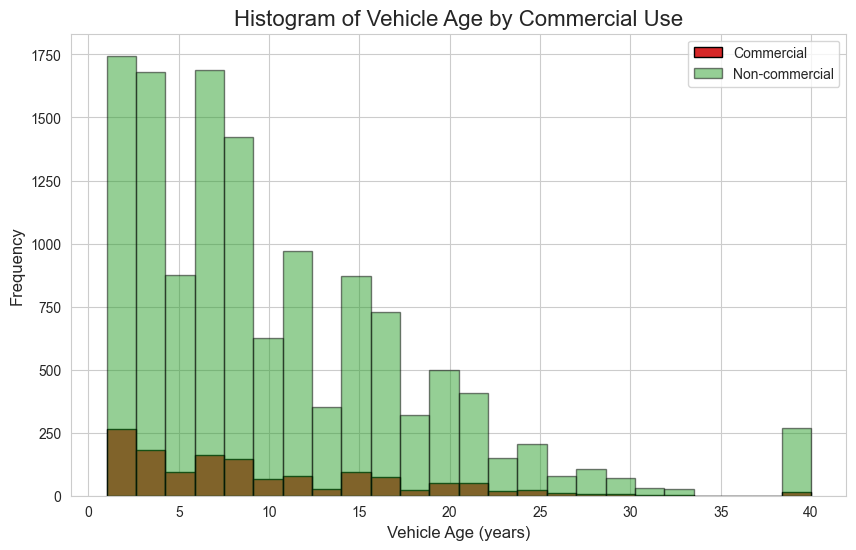

In [50]:
plt.figure(figsize=(10, 6))
urban_comm = NHTS_Data[NHTS_Data['vehicle_commercial'] == 'Yes']['vehicle_age']
plt.hist(urban_comm, bins=24, color='#d62728', edgecolor='black', alpha=1, label='Commercial')
rural_comm = NHTS_Data[NHTS_Data['vehicle_commercial'] == 'No']['vehicle_age']
plt.hist(rural_comm, bins=24, color='#2ca02c', edgecolor='black', alpha=0.5, label='Non-commercial')
plt.xlabel('Vehicle Age (years)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Vehicle Age by Commercial Use', fontsize=16)
plt.legend()
plt.show()

The above graph is a visual representation of vehicle age when compared to commercial and non-commercial vehicle usage.

<Figure size 1200x1000 with 0 Axes>

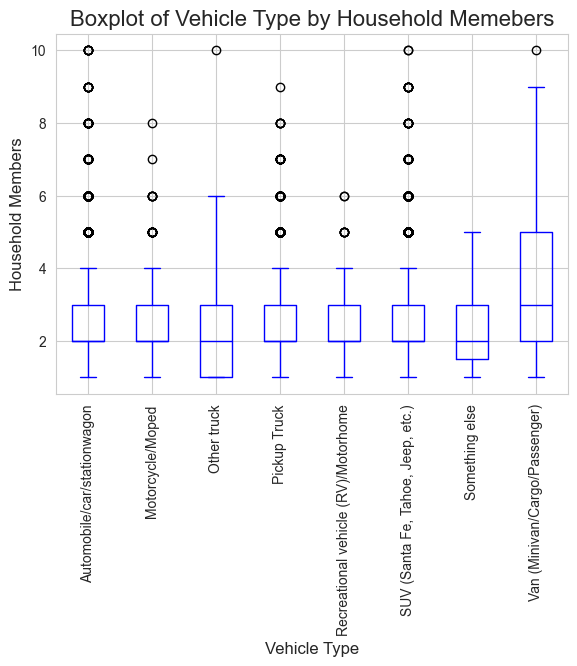

In [125]:
plt.figure(figsize=(12, 10))
sns.boxplot=NHTS_Data.boxplot(column='household_size', by='vehicle_type', rot=90, color = 'Blue')

plt.xlabel('Vehicle Type', fontsize=12)
plt.ylabel('Household Members', fontsize=12)
plt.title('Boxplot of Vehicle Type by Household Memebers', fontsize=16)
plt.suptitle('')
plt.show()

The above code compares the number of household members with the types of vehicles used by the household.

In [98]:
trajectory_number =  10
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]

The above line of code establishes trajectory pair 10 as the pair to be analyzed for the following graphs.

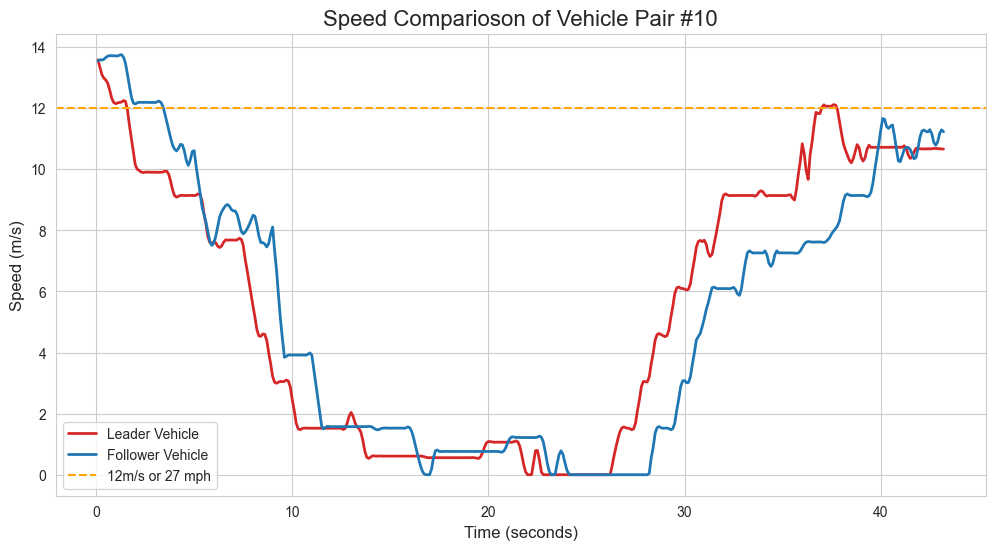

In [124]:
plt.figure(figsize = (12,6))
sns.lineplot(data = data_subset, x = 'Time', y = 'leader_speed(m/s)', label = 'Leader Vehicle', color = '#d62728', linewidth = 2.0)
sns.lineplot(data = data_subset, x = 'Time', y = 'follower_speed(m/s)', label = 'Follower Vehicle', color = '#1f77b4',linewidth = 2.0)
plt.axhline(12, color='orange', linestyle='--', linewidth=1.5, label='12m/s or 27 mph')

plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Speed (m/s)', fontsize=12)
plt.title('Speed Comparioson of Vehicle Pair #10', fontsize=16)
plt.legend()
plt.show()

In [ ]:
The above code and graph are a visual representation of the speeds of the leader and follower vehicle pair 10.

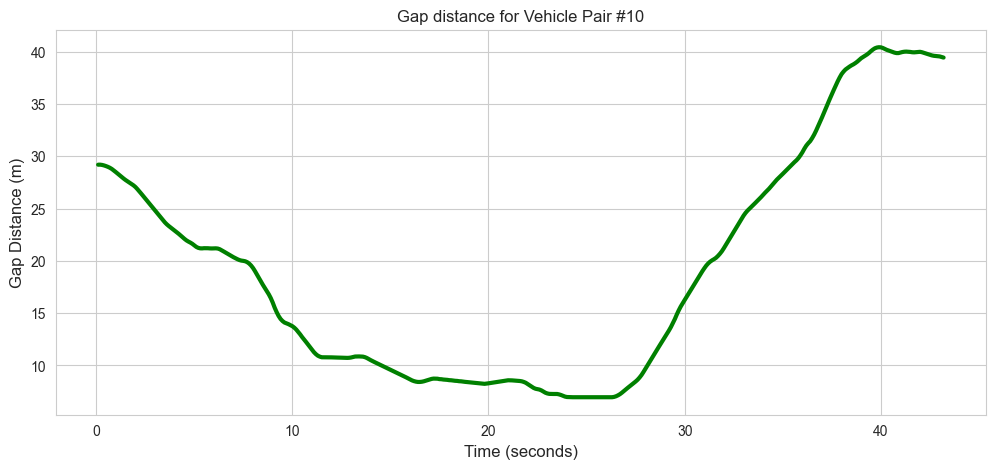

In [127]:
gap_distance = data_subset['leader_position(m)'].values - data_subset['follower_position(m)'].values
plt.figure(figsize = (12,5))
plt.plot(data_subset['Time'], gap_distance, color = 'green', linewidth = 3.0)
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Gap Distance (m)', fontsize=12)
plt.title('Gap distance for Vehicle Pair #10', fontsize=12)
plt.show()


In [ ]:
The above graph represents the gap distance between the two vehicles in Trajectory pair #10.

In [133]:
trajectory_number = 10
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].reset_index(drop = True)

In [134]:
def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))
    s_star = max(s_star, s0)
    acceleration = a * (1 - ((v / v0)**delta) - ((s_star / s)**2))
    return acceleration

In [135]:
v0 = 30
s0 = 2
T = 1.5
a = 1.0
b = 1.5
delta = 4

In [136]:
n_steps = len(time_data)
sim_position = np.zeros(n_steps)
sim_speed = np.zeros(n_steps)
sim_acc = np.zeros(n_steps)
sim_position[0] = data_subset['follower_position(m)'].values[0]
sim_speed[0] = data_subset['follower_speed(m/s)'].values[0]

In [139]:
for i in range(n_steps - 1):
    gap = max(leader_position[i] - sim_position[i], 0.1)
    delta_v = sim_speed[i] - leader_speed[i]
    sim_acc[i] = idm_acceleration(sim_speed[i], gap, delta_v, v0, s0, T, a, b, delta)
    sim_speed[i+1] = max(sim_speed[i] + sim_acc[i]* dt, 0)
    sim_position[i+1] = sim_position[i] + sim_speed[i]* dt

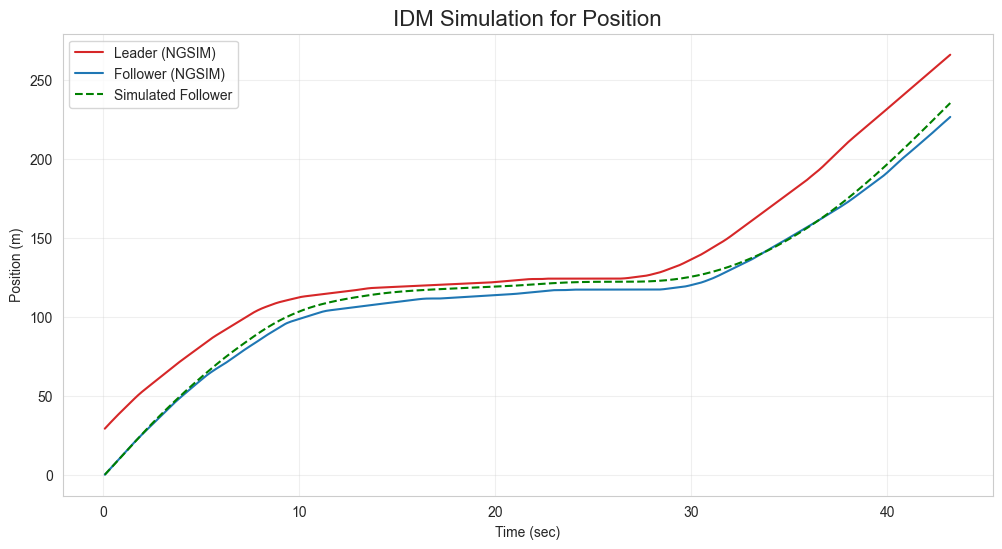

In [155]:
plt.figure(figsize = (12,6))
plt.plot(time_data, leader_position, label = 'Leader (NGSIM)', color = '#d62728')
plt.plot(time_data, data_subset['follower_position(m)'].values, label = 'Follower (NGSIM)', color = '#1f77b4')
plt.plot(time_data, sim_position, label = 'Simulated Follower', color = 'green', linestyle = '--')
plt.xlabel('Time (sec)')
plt.ylabel('Position (m)')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.title('IDM Simulation for Position', fontsize=16)
plt.show()

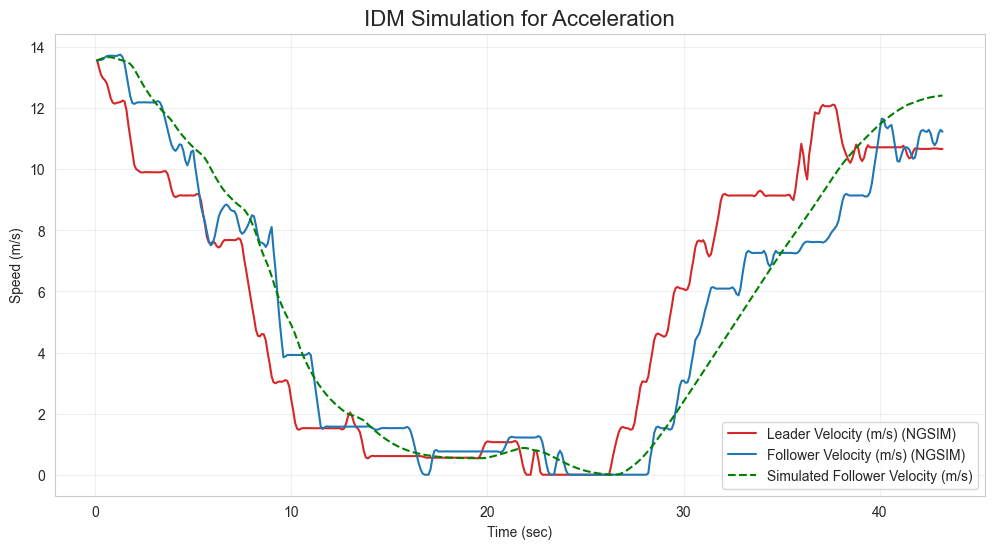

In [157]:
plt.figure(figsize = (12,6))
plt.plot(time_data, data_subset['leader_speed(m/s)'].values, label = 'Leader Velocity (m/s) (NGSIM)', color = '#d62728')
plt.plot(time_data, data_subset['follower_speed(m/s)'].values, label = 'Follower Velocity (m/s) (NGSIM)', color = '#1f77b4')
plt.plot(time_data, sim_speed, label = 'Simulated Follower Velocity (m/s)', color = 'green', linestyle = '--')
plt.xlabel('Time (sec)')
plt.ylabel('Speed (m/s)')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.title('IDM Simulation for Acceleration', fontsize=16)
plt.show()